In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Optional

In [2]:
# =========================================================
# Basic settings
# =========================================================
BASE_DIR = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village")
OUT_DIR = BASE_DIR / "qm_corrected_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

POI_LAT = 25.0190099143756
POI_LON = 121.53137177116402

QM_START = 2004
QM_END   = 2024

FULL_START = 2000
FULL_END   = 2036

SPLIT_YEAR = 2005

VARIABLES = ["tmin", "tmean", "tmax"]
RCPS = ["rcp26", "rcp45", "rcp60", "rcp85"]

In [3]:
FINAL_MODELS_BY_RCP = {
    "rcp26": ['BNU-ESM', 'CCSM4', 'CESM1-CAM5', 'CNRM-CM5', 'CSIRO-Mk3-6-0',
              'CanESM2', 'FGOALS-g2', 'GFDL-CM3', 'GFDL-ESM2G', 'IPSL-CM5A-LR',
              'IPSL-CM5A-MR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5',
              'MPI-ESM-LR', 'MPI-ESM-MR', 'MRI-CGCM3', 'NorESM1-M',
              'bcc-csm1-1', 'bcc-csm1-1-m'],

    "rcp45": ['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC',
              'CESM1-CAM5', 'CMCC-CM', 'CMCC-CMS', 'CNRM-CM5', 'CSIRO-Mk3-6-0',
              'CanESM2', 'FGOALS-g2', 'GFDL-ESM2G', 'GFDL-ESM2M',
              'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'IPSL-CM5B-LR', 'MIROC-ESM',
              'MIROC-ESM-CHEM', 'MIROC5', 'MPI-ESM-LR', 'MPI-ESM-MR',
              'MRI-CGCM3', 'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m', 'inmcm4'],

    "rcp60": ['CCSM4', 'CESM1-CAM5', 'CSIRO-Mk3-6-0', 'GFDL-CM3', 'GFDL-ESM2G',
              'GFDL-ESM2M', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'MIROC-ESM',
              'MIROC-ESM-CHEM', 'MIROC5', 'MRI-CGCM3', 'NorESM1-M',
              'bcc-csm1-1', 'bcc-csm1-1-m'],

    "rcp85": ['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC',
              'CESM1-CAM5', 'CMCC-CESM', 'CMCC-CM', 'CNRM-CM5',
              'CSIRO-Mk3-6-0', 'CanESM2', 'EC-EARTH', 'FGOALS-g2',
              'GFDL-CM3', 'GFDL-ESM2G', 'GFDL-ESM2M', 'IPSL-CM5A-LR',
              'IPSL-CM5A-MR', 'IPSL-CM5B-LR', 'MIROC-ESM', 'MIROC-ESM-CHEM',
              'MIROC5', 'MPI-ESM-LR', 'MPI-ESM-MR', 'MRI-CGCM3', 'MRI-ESM1',
              'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m', 'inmcm4']
}

ALL_NEEDED_MODELS = sorted(set(
    m for models in FINAL_MODELS_BY_RCP.values() for m in models
))

print(f"Total models to correct: {len(ALL_NEEDED_MODELS)}")
print(ALL_NEEDED_MODELS)

Total models to correct: 31
['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC', 'CESM1-CAM5', 'CMCC-CESM', 'CMCC-CM', 'CMCC-CMS', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'EC-EARTH', 'FGOALS-g2', 'GFDL-CM3', 'GFDL-ESM2G', 'GFDL-ESM2M', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'IPSL-CM5B-LR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MPI-ESM-LR', 'MPI-ESM-MR', 'MRI-CGCM3', 'MRI-ESM1', 'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m', 'inmcm4']


In [55]:
# =========================================================
# Data directories
# 請改成你自己的實際路徑
# =========================================================
OBS_DIRS = {
    "tmean": Path(r"C:/觀測_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/觀測_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/觀測_日資料_臺北市_最低溫"),
}

MODEL_DIRS = {
    "tmean": Path(r"C:/AR5_統計降尺度_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/AR5_統計降尺度_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/AR5_統計降尺度_日資料_臺北市_最低溫"),
}

In [56]:
def read_csv_flexible(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    if len(df.columns) == 1:
        df = pd.read_csv(csv_path, encoding="utf-8-sig", sep=None, engine="python")

    df.columns = [
        str(c).strip().replace("\ufeff", "").replace("'", "").replace('"', "")
        for c in df.columns
    ]
    return df


def remove_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")].copy()


def ensure_lat_lon(df: pd.DataFrame) -> pd.DataFrame:
    if "LON" not in df.columns or "LAT" not in df.columns:
        raise KeyError(f"缺少 LON/LAT 欄位，實際欄位為：{df.columns.tolist()[:20]}")
    return df


def get_date_columns(columns, start_year=None, end_year=None):
    out = []
    for c in columns:
        c = str(c)
        if re.fullmatch(r"\d{8}", c):
            y = int(c[:4])
            if start_year is not None and y < start_year:
                continue
            if end_year is not None and y > end_year:
                continue
            out.append(c)
    return sorted(out)


def to_datetime_index(idx):
    return pd.to_datetime(pd.Index(idx).astype(str), format="%Y%m%d", errors="coerce")


def find_nearest_row(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon(df)
    dist2 = (df["LAT"] - target_lat) ** 2 + (df["LON"] - target_lon) ** 2
    idx = dist2.idxmin()
    return df.loc[idx].copy()


def estimate_grid_spacing(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon(df)

    nearest = find_nearest_row(df, target_lat, target_lon)
    lat0 = float(nearest["LAT"])
    lon0 = float(nearest["LON"])

    unique_lats = np.sort(df["LAT"].dropna().unique())
    unique_lons = np.sort(df["LON"].dropna().unique())

    lat_neighbors = unique_lats[np.abs(unique_lats - lat0) > 0]
    lon_neighbors = unique_lons[np.abs(unique_lons - lon0) > 0]

    dlat = float(np.min(np.abs(lat_neighbors - lat0))) if len(lat_neighbors) else 0.05
    dlon = float(np.min(np.abs(lon_neighbors - lon0))) if len(lon_neighbors) else 0.05

    return lat0, lon0, dlat, dlon




In [57]:
def parse_model_filename(file_path: Path):
    file_name = file_path.name

    pattern = (
        r"^AR5_統計降尺度_日資料_"
        r"(?P<region>.+?)_"
        r"(?P<variable>最高溫|平均溫|最低溫|降雨量)_"
        r"(?P<scenario>historical|rcp26|rcp45|rcp60|rcp85)_"
        r"(?P<model>.+?)_"
        r"(?P<year>\d{4})\.csv$"
    )

    m = re.match(pattern, file_name)
    if not m:
        return None

    info = m.groupdict()
    info["year"] = int(info["year"])
    info["path"] = file_path
    info["stem"] = file_path.stem
    return info


def parse_obs_filename(file_path: Path):
    stem = file_path.stem
    matches = re.findall(r"(?:19|20)\d{2}", stem)
    return int(matches[-1]) if matches else None

In [68]:
def build_model_file_index(var_dir: Path, start_year=2000, end_year=2036, verbose=False):
    rows = []
    failed = []

    for fp in var_dir.glob("*.csv"):
        parsed = parse_model_filename(fp)
        if parsed is None:
            failed.append(fp.name)
            continue

        if start_year <= parsed["year"] <= end_year:
            rows.append(parsed)

    if not rows:
        if verbose:
            print(f"[WARN] 在 {var_dir} 找不到符合格式的 CSV 檔案")
        return pd.DataFrame(columns=["region", "variable", "scenario", "model", "year", "path", "stem"])

    df = (
        pd.DataFrame(rows)
        .sort_values(["model", "scenario", "year"])
        .drop_duplicates(subset=["model", "scenario", "year"], keep="first")
        .reset_index(drop=True)
    )
    return df


#def build_obs_file_index(obs_dir: Path, start_year=2004, end_year=2024):
   # rows = []

   # for f in obs_dir.rglob("*.csv"):
    #    year = parse_obs_filename(f)
    #    if year is None:
     #       continue

     #   if start_year <= year <= end_year:
     #       rows.append({"year": year, "path": f})

 #   if not rows:
    #    return pd.DataFrame(columns=["year", "path"])

  #  return (
    #    pd.DataFrame(rows)
     #   .sort_values("year")
      #  .drop_duplicates("year")
       # .reset_index(drop=True)
   # )

def build_obs_file_index(obs_dir: Path, start_year=2004, end_year=2024):
    """
    只抓真正的觀測主檔：
    - 觀測_日資料_臺北市_平均溫_YYYY.csv
    - 觀測_日資料_臺北市_最高溫_YYYY.csv
    - 觀測_日資料_臺北市_最低溫_YYYY.csv

    排除：
    - 參考測站平均距離
    - 參考測站溫度標準差
    """
    rows = []

    obs_dir_name = obs_dir.name
    if "平均溫" in obs_dir_name:
        variable_label = "平均溫"
    elif "最高溫" in obs_dir_name:
        variable_label = "最高溫"
    elif "最低溫" in obs_dir_name:
        variable_label = "最低溫"
    else:
        variable_label = None

    for f in sorted(obs_dir.glob("*.csv")):
        fname = f.name

        # 排除附屬檔
        if "參考測站平均距離" in fname:
            continue
        if "參考測站溫度標準差" in fname:
            continue

        # 若能判斷變數，則只保留主檔
        if variable_label is not None and variable_label not in fname:
            continue

        match = re.search(r"(?:19|20)\d{2}", fname)
        if not match:
            continue

        year = int(match.group(0))
        if not (start_year <= year <= end_year):
            continue

        rows.append({
            "year": year,
            "path": f
        })

    if not rows:
        return pd.DataFrame(columns=["year", "path"])

    return(
        pd.DataFrame(rows)
        .sort_values("year")
        .drop_duplicates(subset=["year"], keep="first")
        .reset_index(drop=True)
    )

   # dfdf = 


In [59]:
def read_model_one_file_nearest(csv_path: Path, target_lat, target_lon):
    df = read_csv_flexible(csv_path)
    df = remove_unnamed_columns(df)
    df = ensure_lat_lon(df)

    nearest = find_nearest_row(df, target_lat, target_lon)

    date_cols = get_date_columns(df.columns)
    if not date_cols:
        return pd.Series(dtype=float), None, None

    s = nearest[date_cols].copy()
    s.index = to_datetime_index(s.index)
    s = pd.to_numeric(s, errors="coerce")
    s = s[~s.index.isna()].sort_index()

    model_lat = float(nearest["LAT"])
    model_lon = float(nearest["LON"])

    return s, model_lat, model_lon

In [60]:
def read_obs_one_year_spatial_mean(csv_path, model_lat, model_lon, dlat, dlon):
    df = read_csv_flexible(csv_path)
    df = remove_unnamed_columns(df)
    df = ensure_lat_lon(df)

    date_cols = get_date_columns(df.columns)
    if not date_cols:
        return pd.Series(dtype=float)

    lat_min = model_lat - dlat / 2
    lat_max = model_lat + dlat / 2
    lon_min = model_lon - dlon / 2
    lon_max = model_lon + dlon / 2

    sub = df[
        (df["LAT"] >= lat_min) & (df["LAT"] <= lat_max) &
        (df["LON"] >= lon_min) & (df["LON"] <= lon_max)
    ].copy()

    if sub.empty:
        nearest = find_nearest_row(df, model_lat, model_lon)
        sub = pd.DataFrame([nearest])

    s = sub[date_cols].mean(axis=0)
    s.index = pd.to_datetime(s.index, format="%Y%m%d")
    s = pd.to_numeric(s, errors="coerce")
    s = s.sort_index()

    return s

In [61]:
def read_obs_daily(variable: str, start_year: int = FULL_START, end_year: int = FULL_END) -> pd.DataFrame:
    obs_dir = OBS_DIRS[variable]
    obs_index = build_obs_file_index(obs_dir, start_year=start_year, end_year=end_year)

    model_dir = MODEL_DIRS[variable]
    model_index = build_model_file_index(model_dir, start_year=QM_START, end_year=QM_END, verbose=False)
    if model_index.empty:
        raise ValueError(f"{variable} 找不到可用模式檔案，無法估算 grid spacing")

    sample_file = model_index.iloc[0]["path"]
    sample_df = read_csv_flexible(sample_file)
    sample_df = remove_unnamed_columns(sample_df)
    sample_df = ensure_lat_lon(sample_df)

    _, _, dlat, dlon = estimate_grid_spacing(sample_df, POI_LAT, POI_LON)
    _, model_lat, model_lon = read_model_one_file_nearest(sample_file, POI_LAT, POI_LON)

    series_list = []
    for year in range(start_year, end_year + 1):
        sub = obs_index[obs_index["year"] == year]
        if sub.empty:
            continue

        f = sub.iloc[0]["path"]
        s = read_obs_one_year_spatial_mean(f, model_lat, model_lon, dlat, dlon)
        s = s[s.index.year == year]

        if not s.empty:
            series_list.append(s)

    if not series_list:
        return pd.DataFrame(columns=["date", "value"])

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    df_out = pd.DataFrame({
        "date": out.index,
        "value": out.values
    }).reset_index(drop=True)

    print("variable =", variable)
    print("year range =", start_year, end_year)
    print("matched files =")
    print(obs_index)

    return df_out

In [62]:
def read_model_daily(variable: str, model: str, scenario: str,
                     start_year: int = FULL_START, end_year: int = FULL_END,
                     split_year: int = SPLIT_YEAR) -> pd.DataFrame:
    model_dir = MODEL_DIRS[variable]
    model_index = build_model_file_index(model_dir, start_year=start_year, end_year=end_year, verbose=False)

    if model_index.empty:
        return pd.DataFrame(columns=["date", "value", "model", "scenario"])

    rows = []

    if scenario == "historical":
        for year in range(start_year, min(end_year, split_year) + 1):
            sub = model_index[
                (model_index["model"] == model) &
                (model_index["scenario"] == "historical") &
                (model_index["year"] == year)
            ]
            if not sub.empty:
                rows.append(sub.iloc[0])

    else:
        for year in range(max(start_year, split_year + 1), end_year + 1):
            sub = model_index[
                (model_index["model"] == model) &
                (model_index["scenario"] == scenario) &
                (model_index["year"] == year)
            ]
            if not sub.empty:
                rows.append(sub.iloc[0])

    if not rows:
        return pd.DataFrame(columns=["date", "value", "model", "scenario"])

    series_list = []
    for row in rows:
        s, _, _ = read_model_one_file_nearest(row["path"], POI_LAT, POI_LON)
        if s.empty:
            continue

        s = s[s.index.year == row["year"]]
        if not s.empty:
            series_list.append(s)

    if not series_list:
        return pd.DataFrame(columns=["date", "value", "model", "scenario"])

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    df_out = pd.DataFrame({
        "date": out.index,
        "value": out.values,
        "model": model,
        "scenario": scenario
    }).reset_index(drop=True)

    return df_out

In [53]:
#test
def read_obs_daily(variable: str, start_year: int = FULL_START, end_year: int = FULL_END) -> pd.DataFrame:
    obs_dir = OBS_DIRS[variable]
    obs_index = build_obs_file_index(obs_dir, start_year=start_year, end_year=end_year)

    print("=== read_obs_daily debug ===")
    print("variable:", variable)
    print("obs_dir:", obs_dir)
    print("obs_index len:", len(obs_index))
    print(obs_index.head())

    model_dir = MODEL_DIRS[variable]
    model_index = build_model_file_index(model_dir, start_year=QM_START, end_year=QM_END, verbose=False)
    print("model_index len:", len(model_index))

    if model_index.empty:
        raise ValueError(f"{variable} 找不到可用模式檔案，無法估算 grid spacing")

    sample_file = model_index.iloc[0]["path"]
    print("sample_file:", sample_file)

    sample_df = read_csv_flexible(sample_file)
    sample_df = remove_unnamed_columns(sample_df)
    sample_df = ensure_lat_lon(sample_df)

    _, _, dlat, dlon = estimate_grid_spacing(sample_df, POI_LAT, POI_LON)
    _, model_lat, model_lon = read_model_one_file_nearest(sample_file, POI_LAT, POI_LON)

    print("model_lat, model_lon:", model_lat, model_lon)
    print("dlat, dlon:", dlat, dlon)

    series_list = []
    for year in range(start_year, end_year + 1):
        sub = obs_index[obs_index["year"] == year]
        print(f"\nyear = {year}, matched obs files = {len(sub)}")

        if sub.empty:
            continue

        f = sub.iloc[0]["path"]
        print("obs file:", f)

        s = read_obs_one_year_spatial_mean(f, model_lat, model_lon, dlat, dlon)

        print("raw series len:", len(s))
        if len(s) > 0:
            print("raw series head:")
            print(s.head())

        s = s[s.index.year == year]
        print("after year filter len:", len(s))

        if not s.empty:
            series_list.append(s)

    print("\nfinal series_list len:", len(series_list))

    if not series_list:
        return pd.DataFrame(columns=["date", "value"])

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    df_out = pd.DataFrame({
        "date": out.index,
        "value": out.values
    }).reset_index(drop=True)

    print("final df_out shape:", df_out.shape)
    print(df_out.head())

    return df_out

In [69]:
obs_tmean = read_obs_daily("tmean", 2004, 2024)
print(obs_tmean.head())
print(obs_tmean.shape)

variable = tmean
year range = 2004 2024
matched files =
    year                                       path
0   2004  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2004.csv
1   2005  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2005.csv
2   2006  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2006.csv
3   2007  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2007.csv
4   2008  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2008.csv
5   2009  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2009.csv
6   2010  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2010.csv
7   2011  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2011.csv
8   2012  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2012.csv
9   2013  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2013.csv
10  2014  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2014.csv
11  2015  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2015.csv
12  2016  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2016.csv
13  2017  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2017.csv
14  2018  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2018.csv
15  2019  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2019.csv
16  2020  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2020.csv
17  2021

In [47]:
hist_test = read_model_daily("tmean", ALL_NEEDED_MODELS[0], "historical", 2000, 2005)
print(hist_test.head())
print(hist_test.shape)

        date    value      model    scenario
0 2000-01-01  21.8938  ACCESS1-0  historical
1 2000-01-02  23.1696  ACCESS1-0  historical
2 2000-01-03  16.4554  ACCESS1-0  historical
3 2000-01-04  11.2965  ACCESS1-0  historical
4 2000-01-05  11.7164  ACCESS1-0  historical
(2190, 4)


In [14]:
future_test = read_model_daily("tmean", ALL_NEEDED_MODELS[0], "rcp45", 2006, 2036)
print(future_test.head())
print(future_test.shape)

        date    value      model scenario
0 2006-01-01  13.8844  ACCESS1-0    rcp45
1 2006-01-02  13.2522  ACCESS1-0    rcp45
2 2006-01-03  14.8385  ACCESS1-0    rcp45
3 2006-01-04  16.9079  ACCESS1-0    rcp45
4 2006-01-05  16.6635  ACCESS1-0    rcp45
(11315, 4)


In [64]:
def build_qm_mapping(model_hist: np.ndarray, obs_hist: np.ndarray, n_quantiles: int = 200):
    model_hist = np.asarray(model_hist, dtype=float)
    obs_hist = np.asarray(obs_hist, dtype=float)

    model_hist = model_hist[~np.isnan(model_hist)]
    obs_hist = obs_hist[~np.isnan(obs_hist)]

    if len(model_hist) < 30 or len(obs_hist) < 30:
        return None

    qs = np.linspace(0, 1, )
    model_q = np.quantile(model_hist, qs)
    obs_q = np.quantile(obs_hist, qs)

    return {
        "qs": qs,
        "model_q": model_q,
        "obs_q": obs_q
    }


def apply_qm_mapping(values: np.ndarray, qm_obj):
    values = np.asarray(values, dtype=float)

    if qm_obj is None:
        return values.copy()

    corrected = np.interp(
        values,
        qm_obj["model_q"],
        qm_obj["obs_q"],
        left=qm_obj["obs_q"][0],
        right=qm_obj["obs_q"][-1]
    )
    return corrected

In [65]:
def build_monthly_qm_for_model(obs_df: pd.DataFrame, model_hist_df: pd.DataFrame) -> Dict[int, Optional[dict]]:
    df_obs = obs_df.copy()
    df_mod = model_hist_df.copy()

    df_obs["date"] = pd.to_datetime(df_obs["date"])
    df_mod["date"] = pd.to_datetime(df_mod["date"])

    df_obs = df_obs[(df_obs["date"].dt.year >= QM_START) & (df_obs["date"].dt.year <= QM_END)]
    df_mod = df_mod[(df_mod["date"].dt.year >= QM_START) & (df_mod["date"].dt.year <= QM_END)]

    df = pd.merge(
        df_mod[["date", "value"]],
        df_obs[["date", "value"]],
        on="date",
        how="inner",
        suffixes=("_model", "_obs")
    )

    df["month"] = df["date"].dt.month

    qm_monthly = {}
    for m in range(1, 13):
        sub = df[df["month"] == m].copy()

        qm_obj = build_qm_mapping(
            model_hist=sub["value_model"].values,
            obs_hist=sub["value_obs"].values,
            n_quantiles=200
        )
        qm_monthly[m] = qm_obj

    return qm_monthly

In [112]:
import numpy as np
import pandas as pd


def build_monthly_qdm_for_model(obs_df: pd.DataFrame, hist_df: pd.DataFrame):
    obs = obs_df.copy()
    hist = hist_df.copy()

    obs["date"] = pd.to_datetime(obs["date"])
    hist["date"] = pd.to_datetime(hist["date"])

    obs["month"] = obs["date"].dt.month
    hist["month"] = hist["date"].dt.month

    monthly = {}

    for m in range(1, 13):
        obs_vals = obs.loc[obs["month"] == m, "value"].dropna().values
        hist_vals = hist.loc[hist["month"] == m, "value"].dropna().values

        if len(obs_vals) < 10 or len(hist_vals) < 10:
            monthly[m] = None
            continue

        monthly[m] = {
            "obs_sorted": np.sort(obs_vals),
            "hist_sorted": np.sort(hist_vals),
        }

    return monthly


def empirical_cdf_value(x, sorted_arr):
    if len(sorted_arr) == 0:
        return np.nan
    rank = np.searchsorted(sorted_arr, x, side="right")
    p = rank / len(sorted_arr)
    return np.clip(p, 0.0, 1.0)


def quantile_from_sorted(p, sorted_arr):
    if len(sorted_arr) == 0:
        return np.nan
    p = np.clip(p, 0.0, 1.0)
    return np.quantile(sorted_arr, p)


def apply_monthly_qm_to_df(df: pd.DataFrame, qm_monthly):
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    out["month"] = out["date"].dt.month

    corrected = []

    for _, row in out.iterrows():
        m = row["month"]
        x = row["value"]

        info = qm_monthly.get(m)
        if info is None or pd.isna(x):
            corrected.append(np.nan)
            continue

        qs = info["qs"]
        model_q = info["model_q"]
        obs_q = info["obs_q"]

        # 一般 QM：x 在 historical model quantile curve 上的位置
        y = np.interp(
            x,
            model_q,
            obs_q,
            left=obs_q[0],
            right=obs_q[-1]
        )

        corrected.append(y)

    out["value_corrected"] = corrected
    return out

def apply_monthly_qdm_to_future_df(df: pd.DataFrame, qm_monthly):
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    out["month"] = out["date"].dt.month

    corrected = []

    for _, row in out.iterrows():
        m = row["month"]
        x_fut = row["value"]

        info = qm_monthly.get(m)
        if info is None or pd.isna(x_fut):
            corrected.append(np.nan)
            continue

        qs = info["qs"]
        model_q = info["model_q"]
        obs_q = info["obs_q"]

        # 1) 先找 future 值在 historical model quantile curve 上的位置 p
        p = np.interp(
            x_fut,
            model_q,
            qs,
            left=qs[0],
            right=qs[-1]
        )

        # 2) 找同一個 p 下，historical model 與 obs 的分位值
        x_hist_q = np.interp(
            p,
            qs,
            model_q,
            left=model_q[0],
            right=model_q[-1]
        )

        x_obs_q = np.interp(
            p,
            qs,
            obs_q,
            left=obs_q[0],
            right=obs_q[-1]
        )

        # 3) 加法型 QDM：保留 future 相對 historical model 的增量
        y_fut = x_obs_q + (x_fut - x_hist_q)
        corrected.append(y_fut)

    out["value_corrected"] = corrected
    return out

In [114]:
all_outputs = []

for variable in VARIABLES:
    print(f"\n===== Processing {variable} =====")

    obs_df = read_obs_daily(variable, FULL_START, FULL_END)
    obs_df["date"] = pd.to_datetime(obs_df["date"])

    for rcp in RCPS:
        model_list = FINAL_MODELS_BY_RCP[rcp]

        for model_name in model_list:
            print(f"Processing {variable} | {model_name} | {rcp}")

            hist_df = read_model_daily(
                variable=variable,
                model=model_name,
                scenario="historical",
                start_year=FULL_START,
                end_year=FULL_END
            )

            fut_df = read_model_daily(
                variable=variable,
                model=model_name,
                scenario=rcp,
                start_year=FULL_START,
                end_year=FULL_END
            )

            if hist_df.empty or fut_df.empty:
                print("  -> skip (missing hist or future)")
                continue

            qm_monthly = build_monthly_qm_for_model(obs_df, hist_df)

            hist_corr = apply_monthly_qm_to_df(hist_df, qm_monthly)
            hist_corr["value"] = hist_corr["value_corrected"]
            hist_corr["variable"] = variable

            fut_corr =  apply_monthly_qdm_to_future_df(fut_df, qm_monthly)
            fut_corr["value"] = fut_corr["value_corrected"]
            fut_corr["variable"] = variable
            

            keep_cols = ["date", "value", "model", "scenario", "variable"]

            all_outputs.append(hist_corr[keep_cols].copy())
            all_outputs.append(fut_corr[keep_cols].copy())


===== Processing tmin =====
variable = tmin
year range = 2000 2036
matched files =
    year                                       path
0   2000  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2000.csv
1   2001  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2001.csv
2   2002  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2002.csv
3   2003  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2003.csv
4   2004  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2004.csv
5   2005  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2005.csv
6   2006  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2006.csv
7   2007  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2007.csv
8   2008  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2008.csv
9   2009  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2009.csv
10  2010  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2010.csv
11  2011  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2011.csv
12  2012  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2012.csv
13  2013  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2013.csv
14  2014  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2014.csv
15  2015  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_2015.csv
16  2016  C:\觀測_日資料_臺北市_最低溫\觀測_日

In [115]:
corrected_all = pd.concat(all_outputs, axis=0).reset_index(drop=True)

corrected_all["date"] = pd.to_datetime(corrected_all["date"])
corrected_all["year"] = corrected_all["date"].dt.year
corrected_all["month"] = corrected_all["date"].dt.month

corrected_all = corrected_all[
    (corrected_all["year"] >= FULL_START) &
    (corrected_all["year"] <= FULL_END)
].copy()

print(corrected_all.head())
print(corrected_all.shape)



        date      value    model    scenario variable  year  month
0 2000-01-01  14.762633  BNU-ESM  historical     tmin  2000      1
1 2000-01-02   8.735450  BNU-ESM  historical     tmin  2000      1
2 2000-01-03  11.946228  BNU-ESM  historical     tmin  2000      1
3 2000-01-04  10.344160  BNU-ESM  historical     tmin  2000      1
4 2000-01-05  11.063667  BNU-ESM  historical     tmin  2000      1
(3727380, 7)


In [143]:
for var in VARIABLES:
    sub = corrected_all[corrected_all["variable"] == var].copy()
    var_path = OUT_DIR / f"{var}_corrected_daily_final_models.parquet"
    sub.to_parquet(var_path, index=False)
    print(f"Saved: {var_path}")

Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmin_corrected_daily_final_models.parquet
Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmean_corrected_daily_final_models.parquet
Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmax_corrected_daily_final_models.parquet


In [38]:
print(fut_df["date"].min(), fut_df["date"].max())
print(hist_df["date"].min(), hist_df["date"].max())

print(len(obs_df), len(hist_df))

2006-01-01 00:00:00 2036-12-31 00:00:00
2000-01-01 00:00:00 2005-12-31 00:00:00
0 2190


In [117]:
print("future raw p90:", fut_df["value"].quantile(0.9))
print("future corr p90:", fut_corr["value"].quantile(0.9))
print("obs p90:", obs_df["value"].quantile(0.9))


future raw p90: 34.53104
future corr p90: 34.48536741516814
obs p90: 34.287555


In [124]:
raw_days = fut_df.assign(year=pd.to_datetime(fut_df["date"]).dt.year) \
                 .groupby("year")["value"].apply(lambda s: (s >= 30).sum())

corr_days = fut_corr.assign(year=pd.to_datetime(fut_corr["date"]).dt.year) \
                    .groupby("year")["value"].apply(lambda s: (s >= 30).sum())


raw_annual = fut_df.groupby(pd.to_datetime(fut_df["date"]).dt.year)["value"].mean()
corr_annual = fut_corr.groupby(pd.to_datetime(fut_corr["date"]).dt.year)["value"].mean()

print("raw annual slope:", np.polyfit(raw_annual.index, raw_annual.values, 1)[0])
print("corr annual slope:", np.polyfit(corr_annual.index, corr_annual.values, 1)[0])
print("raw slope:", np.polyfit(raw_days.index, raw_days.values, 1)[0])
print("corr slope:", np.polyfit(corr_days.index, corr_days.values, 1)[0])


raw annual slope: -0.0037639243261146766
corr annual slope: -0.003208715156740436
raw slope: 0.1500000000000268
corr slope: 0.01370967741938637


In [125]:
test_var = "tmean"
test_model = "ACCESS1-0"
test_rcp = "rcp45"

sub_obs = obs_df.copy()
sub_hist_raw = hist_df.copy()
sub_hist_corr = hist_corr.copy()

In [126]:
print("raw_vs_obs shape:", raw_vs_obs.shape)
print("corr_vs_obs shape:", corr_vs_obs.shape)

print("raw_vs_obs head:")
print(raw_vs_obs.head())

print("corr_vs_obs head:")
print(corr_vs_obs.head())

raw_vs_obs shape: (730, 3)
corr_vs_obs shape: (730, 3)
raw_vs_obs head:
        date    model        obs
0 2004-01-01  11.0532  17.387062
1 2004-01-02  11.4339  16.795592
2 2004-01-03  10.6985  18.249771
3 2004-01-04  10.8123  20.722346
4 2004-01-05  13.0041  21.278971
corr_vs_obs head:
        date      model        obs
0 2004-01-01   9.556280  17.387062
1 2004-01-02   9.755465  16.795592
2 2004-01-03   8.412714  18.249771
3 2004-01-04   8.894617  20.722346
4 2004-01-05  11.715187  21.278971


In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calc_metrics(df):
    diff = df["model"] - df["obs"]
    return pd.Series({
        "bias_mean": diff.mean(),
        "mae": diff.abs().mean(),
        "rmse": np.sqrt((diff ** 2).mean()),
        "corr": df["model"].corr(df["obs"]),
        "n_days": len(df)
    })
    

In [128]:
obs_df = read_obs_daily(test_var, FULL_START, FULL_END)
obs_df["date"] = pd.to_datetime(obs_df["date"])

hist_raw = read_model_daily(
    variable=test_var,
    model=test_model,
    scenario="historical",
    start_year=FULL_START,
    end_year=FULL_END
)
hist_raw["date"] = pd.to_datetime(hist_raw["date"])

fut_raw = read_model_daily(
    variable=test_var,
    model=test_model,
    scenario=test_rcp,
    start_year=FULL_START,
    end_year=FULL_END
)
fut_raw["date"] = pd.to_datetime(fut_raw["date"])

print("obs:", obs_df.shape)
print("hist_raw:", hist_raw.shape)
print("fut_raw:", fut_raw.shape)

variable = tmean
year range = 2000 2036
matched files =
    year                                       path
0   2000  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2000.csv
1   2001  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2001.csv
2   2002  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2002.csv
3   2003  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2003.csv
4   2004  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2004.csv
5   2005  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2005.csv
6   2006  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2006.csv
7   2007  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2007.csv
8   2008  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2008.csv
9   2009  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2009.csv
10  2010  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2010.csv
11  2011  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2011.csv
12  2012  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2012.csv
13  2013  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2013.csv
14  2014  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2014.csv
15  2015  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2015.csv
16  2016  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2016.csv
17  2017

In [130]:
qdm_monthly = build_monthly_qdm_for_model(obs_df, hist_raw)

hist_corr = apply_monthly_qm_to_df(hist_raw, qm_monthly)
fut_corr  = apply_monthly_qdm_to_future_df(fut_raw, qm_monthly)

hist_corr["date"] = pd.to_datetime(hist_corr["date"])
fut_corr["date"] = pd.to_datetime(fut_corr["date"])

hist_corr["value"] = hist_corr["value_corrected"]
fut_corr["value"] = fut_corr["value_corrected"]

In [77]:
#丟棄
qm_monthly = build_monthly_qm_for_model(obs_df, hist_raw)

hist_corr = apply_monthly_qm_to_df(hist_raw, qm_monthly)
fut_corr = apply_monthly_qm_to_df(fut_raw, qm_monthly)

hist_corr["date"] = pd.to_datetime(hist_corr["date"])
fut_corr["date"] = pd.to_datetime(fut_corr["date"])

# 用 corrected 值覆蓋 value（方便後面分析）
hist_corr["value"] = hist_corr["value_corrected"]
fut_corr["value"] = fut_corr["value_corrected"]

print("hist_corr:", hist_corr.shape)
print("fut_corr:", fut_corr.shape)

hist_corr: (2190, 6)
fut_corr: (11315, 6)


In [131]:
obs_qm = obs_df[
    (obs_df["date"].dt.year >= QM_START) &
    (obs_df["date"].dt.year <= QM_END)
].copy()

hist_raw_qm = hist_raw[
    (hist_raw["date"].dt.year >= QM_START) &
    (hist_raw["date"].dt.year <= QM_END)
].copy()

hist_corr_qm = hist_corr[
    (hist_corr["date"].dt.year >= QM_START) &
    (hist_corr["date"].dt.year <= QM_END)
].copy()

In [132]:
raw_vs_obs = pd.merge(
    hist_raw_qm[["date", "value"]],
    obs_qm[["date", "value"]],
    on="date",
    how="inner",
    suffixes=("_model", "_obs")
).rename(columns={"value_model": "model", "value_obs": "obs"})

corr_vs_obs = pd.merge(
    hist_corr_qm[["date", "value"]],
    obs_qm[["date", "value"]],
    on="date",
    how="inner",
    suffixes=("_model", "_obs")
).rename(columns={"value_model": "model", "value_obs": "obs"})

metrics_raw = calc_metrics(raw_vs_obs)
metrics_corr = calc_metrics(corr_vs_obs)

metrics_compare = pd.DataFrame({
    "raw_hist_vs_obs": metrics_raw,
    "corrected_hist_vs_obs": metrics_corr
    
})

display(metrics_compare)

,raw_hist_vs_obs,corrected_hist_vs_obs
bias_mean,1.079930,0.069834
mae,2.840526,2.837437
rmse,3.696495,3.693656
corr,0.789157,0.786257
n_days,730.000000,730.000000


In [137]:
improvement = pd.Series({
    "bias_abs_reduction": abs(metrics_raw["bias_mean"]) - abs(metrics_corr["bias_mean"]),
    "mae_reduction": metrics_raw["mae"] - metrics_corr["mae"],
    "rmse_reduction": metrics_raw["rmse"] - metrics_corr["rmse"],
    "corr_change": metrics_corr["corr"] - metrics_raw["corr"]
})

display(improvement.to_frame("improvement"))

,improvement
bias_abs_reduction,1.010096
mae_reduction,0.003088
rmse_reduction,0.002839
corr_change,-0.002901


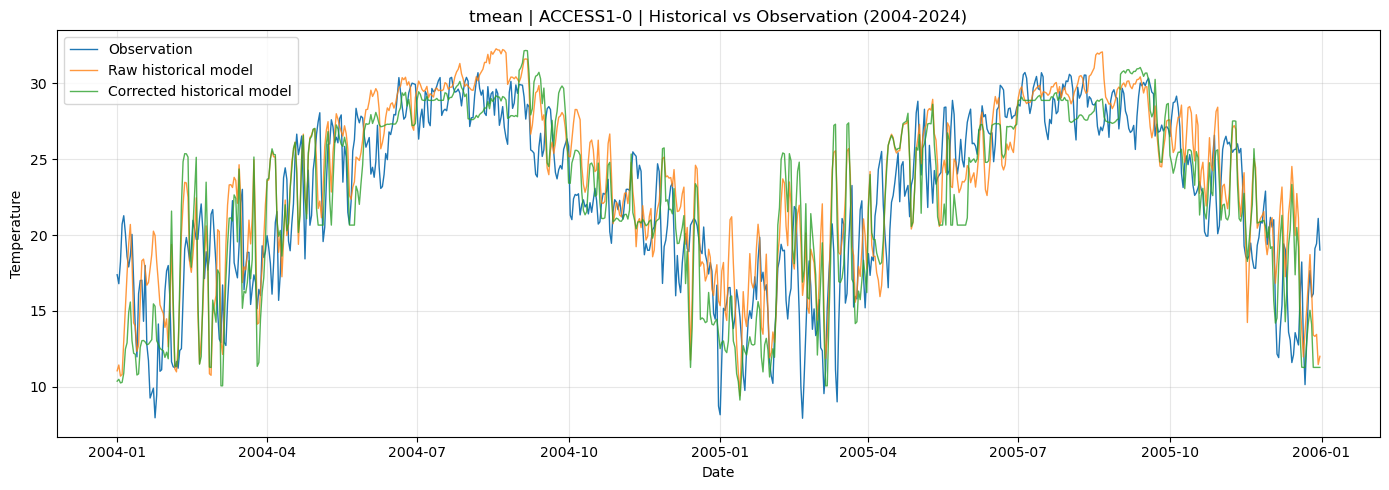

In [142]:
plot_df = raw_vs_obs[["date", "model", "obs"]].rename(columns={"model": "raw_model"})
plot_df = pd.merge(
    plot_df,
    corr_vs_obs[["date", "model"]].rename(columns={"model": "corrected_model"}),
    on="date",
    how="inner"
)

plt.figure(figsize=(14, 5))
plt.plot(plot_df["date"], plot_df["obs"], label="Observation", linewidth=1)
plt.plot(plot_df["date"], plot_df["raw_model"], label="Raw historical model", linewidth=1, alpha=0.8)
plt.plot(plot_df["date"], plot_df["corrected_model"], label="Corrected historical model", linewidth=1, alpha=0.8)

plt.title(f"{test_var} | {test_model} | Historical vs Observation ({QM_START}-{QM_END})")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
# variance check
print("obs std:", obs_tmean["value"].std())
print("raw std:", raw_vs_obs["model"].std())
print("corrected std:", corr_vs_obs["model"].std())

obs std: 5.369974147140297
raw std: 5.336380143068099
corrected std: 5.543664756057557


In [93]:
# 高溫端（例如 >90 percentile）
print("raw p90:", raw_vs_obs["model"].quantile(0.9))
print("corr p90:", corr_vs_obs["model"].quantile(0.9))
print("obs p90:", raw_vs_obs["obs"].quantile(0.9))

raw p90: 29.93699
corr p90: 29.375659117398033
obs p90: 29.37918541666667


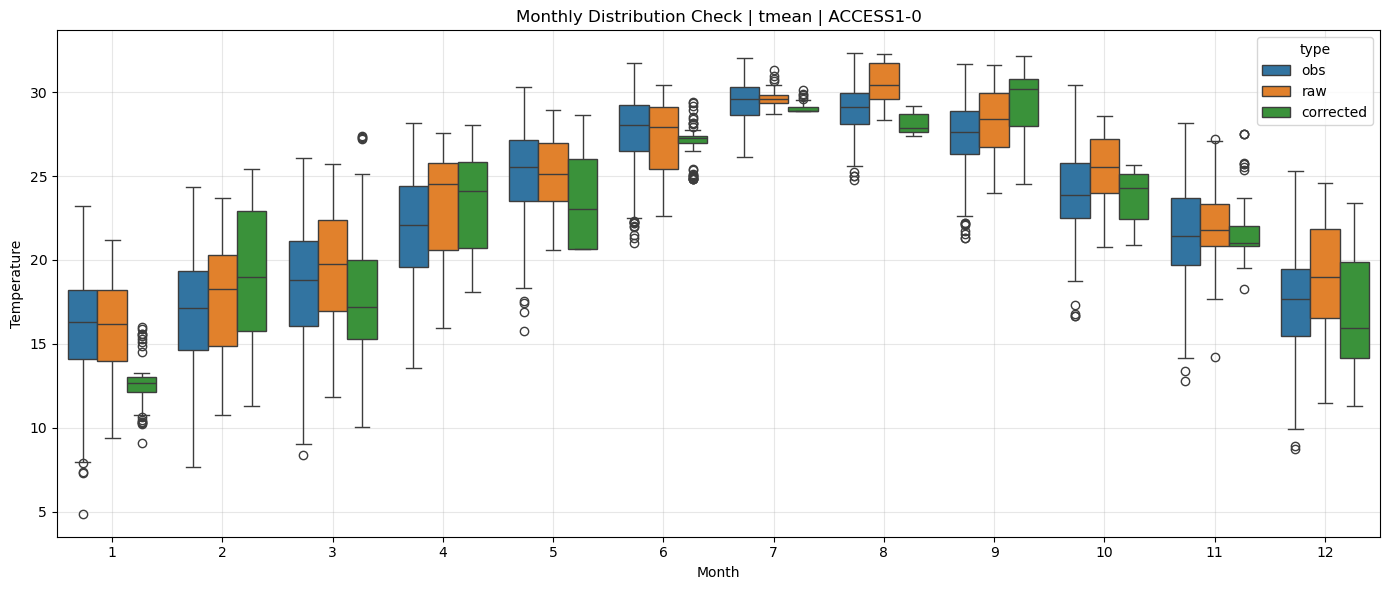

In [133]:
obs_box = obs_qm.copy()
obs_box["type"] = "obs"
obs_box["month"] = obs_box["date"].dt.month

hist_raw_box = hist_raw_qm.copy()
hist_raw_box["type"] = "raw"
hist_raw_box["month"] = hist_raw_box["date"].dt.month

hist_corr_box = hist_corr_qm.copy()
hist_corr_box["type"] = "corrected"
hist_corr_box["month"] = hist_corr_box["date"].dt.month

box_df = pd.concat([
    obs_box[["month", "value", "type"]],
    hist_raw_box[["month", "value", "type"]],
    hist_corr_box[["month", "value", "type"]],
], axis=0)

import seaborn as sns

plt.figure(figsize=(14, 6))
sns.boxplot(data=box_df, x="month", y="value", hue="type")
plt.title(f"Monthly Distribution Check | {test_var} | {test_model}")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [134]:
def count_threshold_days(df, lower=None, upper=None, inclusive_lower=True, inclusive_upper=False):
    s = df["value"].copy()

    cond = pd.Series(True, index=df.index)

    if lower is not None:
        if inclusive_lower:
            cond &= (s >= lower)
        else:
            cond &= (s > lower)

    if upper is not None:
        if inclusive_upper:
            cond &= (s <= upper)
        else:
            cond &= (s < upper)

    out = df.loc[cond].copy()
    out["year"] = out["date"].dt.year

    return out.groupby("year").size().rename("n_days").reset_index()

    

In [135]:
raw_thresh = count_threshold_days(hist_raw_qm, lower=28, upper=31, inclusive_lower=True, inclusive_upper=False)
corr_thresh = count_threshold_days(hist_corr_qm, lower=28, upper=31, inclusive_lower=True, inclusive_upper=False)

threshold_compare = pd.merge(
    raw_thresh.rename(columns={"n_days": "raw_days"}),
    corr_thresh.rename(columns={"n_days": "corrected_days"}),
    on="year",
    how="outer"
).fillna(0)

display(threshold_compare.head())

,year,raw_days,corrected_days
0,2004,85,72
1,2005,91,62


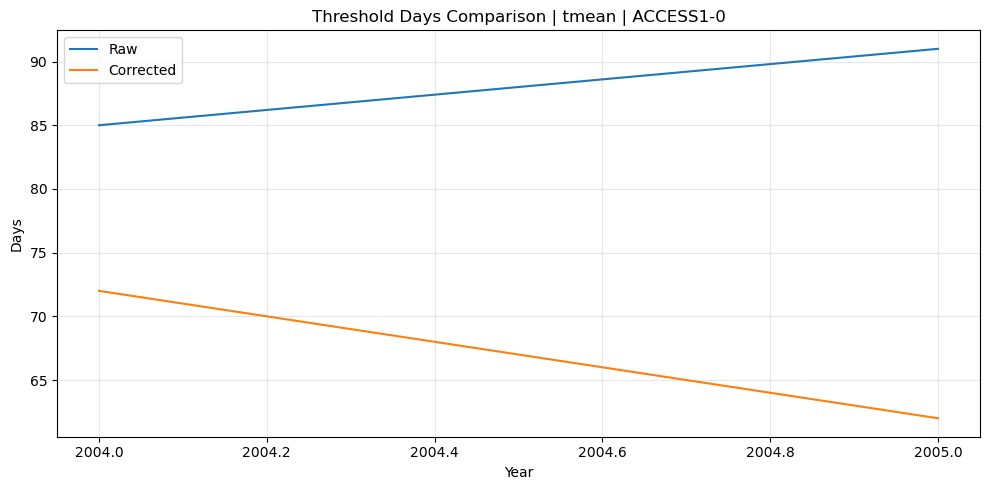

In [136]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_compare["year"], threshold_compare["raw_days"], label="Raw")
plt.plot(threshold_compare["year"], threshold_compare["corrected_days"], label="Corrected")
plt.title(f"Threshold Days Comparison | {test_var} | {test_model}")
plt.xlabel("Year")
plt.ylabel("Days")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#世代數

In [140]:
Tb = 15.9

DD_gen = 650
raw_df = fut_df.copy()

raw_df["date"] = pd.to_datetime(raw_df["date"])
raw_df["year"] = raw_df["date"].dt.year

# 計算 Degree-Day
raw_df["DD"] = (raw_df["value"] - Tb).clip(lower=0)

# 年累積
raw_annual_DD = raw_df.groupby("year")["DD"].sum()

# 世代數
raw_gen = raw_annual_DD / DD_gen
corr_df = fut_corr.copy()

corr_df["date"] = pd.to_datetime(corr_df["date"])
corr_df["year"] = corr_df["date"].dt.year

# 計算 Degree-Day
corr_df["DD"] = (corr_df["value"] - Tb).clip(lower=0)

# 年累積
corr_annual_DD = corr_df.groupby("year")["DD"].sum()

# 世代數
corr_gen = corr_annual_DD / DD_gen

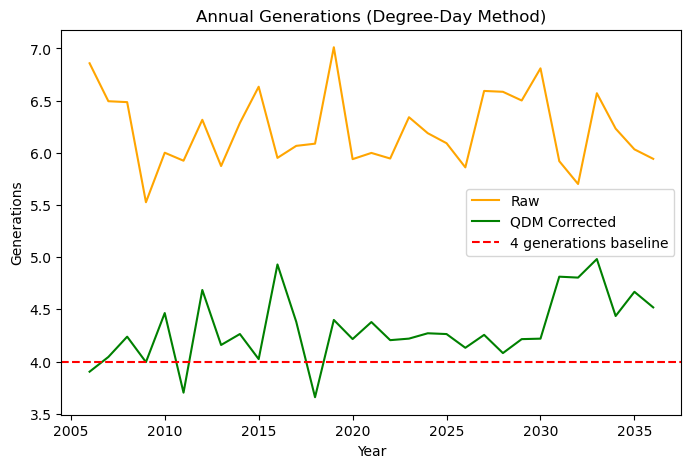

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(raw_gen.index, raw_gen, label="Raw", color="orange")
plt.plot(corr_gen.index, corr_gen, label="QDM Corrected", color="green")

plt.axhline(4, color="red", linestyle="--", label="4 generations baseline")

plt.xlabel("Year")
plt.ylabel("Generations")
plt.title("Annual Generations (Degree-Day Method)")
plt.legend()

plt.show()